<a href="https://colab.research.google.com/github/Roshni-AngelAlex/DEEP-LEARNING/blob/main/24BAD101_DL_Assignment3_RNN_LSTM_GRU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3 – Comparative Analysis of RNN, LSTM and GRU for Sentiment Analysis

**Course:** 24ADI006 Deep Learning

**Name: ROSHNI ANGEL A / Roll no: 24BAD101**

**Objective:** Implement and compare Simple RNN, LSTM and GRU models for binary sentiment classification, using Accuracy, Precision, Recall, F1-score and Training Time.

**Pipeline:** dataset selection → text preprocessing (cleaning, tokenization, padding) → model implementation → evaluation → analysis.

## 1. Setup

In [1]:
import os, re, time, random, warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")
from collections import Counter
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import nltk
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from keras import layers

nltk.download("twitter_samples", quiet=True)
from nltk.corpus import twitter_samples
os.makedirs("figs", exist_ok=True)
print("TensorFlow", tf.__version__)

TensorFlow 2.20.0


## 2. Dataset selection
**Dataset:** *NLTK Twitter Samples* – 10,000 English tweets (5,000 positive, 5,000 negative) labelled for sentiment polarity. It is a standard, publicly available binary sentiment corpus; it is perfectly balanced, so accuracy is a fair headline metric while precision, recall and F1 show *how* each model errs. After cleaning, tweets are very short (about 10 tokens on average), so all three recurrent models can be trained on a CPU with several random seeds.

In [2]:
texts, labels = [], []
for fname, lab in [("negative_tweets.json", 0), ("positive_tweets.json", 1)]:
    for t in twitter_samples.strings(fname):
        texts.append(t); labels.append(lab)
labels = np.array(labels)
print("Total tweets:", len(texts), "| class counts:", dict(Counter(labels)))
print("\nSample tweets:")
for i in [0, 1, 5000, 5001]: print(f"  [{labels[i]}]", texts[i])

Total tweets: 10000 | class counts: {np.int64(0): 5000, np.int64(1): 5000}

Sample tweets:
  [0] hopeless for tmr :(
  [0] Everything in the kids section of IKEA is so cute. Shame I'm nearly 19 in 2 months :(
  [1] #FollowFriday @France_Inte @PKuchly57 @Milipol_Paris for being top engaged members in my community this week :)
  [1] @Lamb2ja Hey James! How odd :/ Please call our Contact Centre on 02392441234 and we will be able to assist you :) Many thanks!


## 3. Text preprocessing
Steps: **(a) cleaning** – lowercase; remove @mentions, URLs, the `#` symbol (hashtag words are kept), digits, punctuation and emoticon characters; **(b) de-duplication** – retweets create identical texts that could appear in both train and test, so exact duplicates are dropped; **(c) tokenization** – whitespace split and integer encoding with a vocabulary built from the *training set only* (prevents data leakage); **(d) padding/truncation** – every tweet is fixed to MAXLEN tokens.

Stop-words are deliberately **not** removed: words such as *not*, *no*, *never* flip polarity, and sequence models need them to learn negation.

After cleaning + de-duplication: 9171 tweets | class counts: {np.int64(0): 4761, np.int64(1): 4410}

BEFORE: hopeless for tmr :(
AFTER : hopeless for tmr

BEFORE: Everything in the kids section of IKEA is so cute. Shame I'm nearly 19 in 2 months :(
AFTER : everything in the kids section of ikea is so cute shame i'm nearly in months

Tweet length (tokens): mean=9.6, median=8, 95th pct=22, max=30  -> MAXLEN = 30


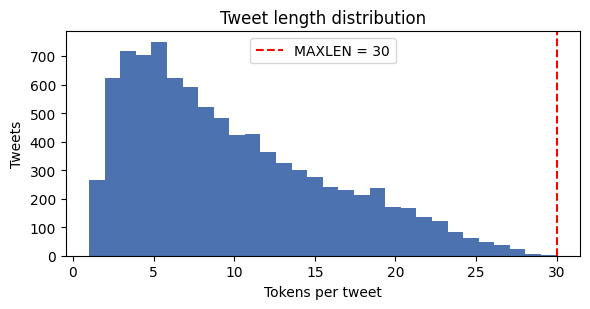

In [3]:
def clean_text(t):
    t = t.lower()
    t = re.sub(r"http\S+|www\.\S+", " ", t)   # URLs
    t = re.sub(r"@\w+", " ", t)                  # @mentions
    t = re.sub(r"#", " ", t)                      # keep hashtag word, drop '#'
    t = re.sub(r"[^a-z' ]+", " ", t)              # digits, punctuation, emoji
    toks = [w for w in t.split() if len(w) > 1 or w in ("a", "i")]  # drops leftover emoticon letters (":D" -> "d")
    return " ".join(toks)

clean_all = [clean_text(t) for t in texts]
# drop empty and exact-duplicate texts (retweets)
seen, keep = set(), []
for i, c in enumerate(clean_all):
    if c and c not in seen: seen.add(c); keep.append(i)
clean = [clean_all[i] for i in keep]; labels = labels[keep]
print(f"After cleaning + de-duplication: {len(clean)} tweets | class counts: {dict(Counter(labels))}")
for i in [0, 1]: print("\nBEFORE:", texts[keep[i]]); print("AFTER :", clean[i])
lens = np.array([len(c.split()) for c in clean])
MAXLEN = 30
print(f"\nTweet length (tokens): mean={lens.mean():.1f}, median={np.median(lens):.0f}, 95th pct={np.percentile(lens,95):.0f}, max={lens.max()}  -> MAXLEN = {MAXLEN}")
plt.figure(figsize=(6,3.2)); plt.hist(lens, bins=30, color="#4C72B0"); plt.axvline(MAXLEN, color="r", ls="--", label=f"MAXLEN = {MAXLEN}")
plt.xlabel("Tokens per tweet"); plt.ylabel("Tweets"); plt.title("Tweet length distribution"); plt.legend(); plt.tight_layout()
plt.savefig("figs/length_hist.png", dpi=150); plt.show()

In [4]:
# Train / validation / test split (stratified): 70% / 10% / 20%
idx = np.arange(len(clean))
tr_val, te = train_test_split(idx, test_size=0.20, stratify=labels, random_state=42)
tr, va = train_test_split(tr_val, test_size=0.125, stratify=labels[tr_val], random_state=42)
print("train/val/test:", len(tr), len(va), len(te))

# Vocabulary from TRAIN only; index 0 = PAD, 1 = OOV
VOCAB = 8000
cnt = Counter(w for i in tr for w in clean[i].split())
itos = ["<PAD>", "<OOV>"] + [w for w, _ in cnt.most_common(VOCAB - 2)]
stoi = {w: i for i, w in enumerate(itos)}
print("Unique train words:", len(cnt), "| vocabulary kept:", len(itos))

def encode(ids):
    seqs = [[stoi.get(w, 1) for w in clean[i].split()] for i in ids]
    # pre-padding puts the real tokens next to the output layer
    return keras.utils.pad_sequences(seqs, maxlen=MAXLEN, padding="pre", truncating="post")

X_tr, X_va, X_te = encode(tr), encode(va), encode(te)
y_tr, y_va, y_te = labels[tr], labels[va], labels[te]
print("X_train:", X_tr.shape, "| example ids:", X_tr[0][-12:])

train/val/test: 6419 917 1835
Unique train words: 9368 | vocabulary kept: 8000
X_train: (6419, 30) | example ids: [   5  260   31  103 1315   13   18 3422    2  195  138 3423]


## 4. Model implementation
All three models share the **same architecture and hyper-parameters** so that only the recurrent cell differs (fair comparison):

`Embedding(8000, 64, mask_zero=True) → {SimpleRNN | LSTM | GRU}(64) → Dropout(0.3) → Dense(1, sigmoid)`

Loss: binary cross-entropy · Optimiser: Adam (lr = 1e-3) · Batch size: 64 · Max 20 epochs with early stopping on validation loss (patience 3, best weights restored).

In [5]:
def build_model(cell):
    Cell = {"RNN": layers.SimpleRNN, "LSTM": layers.LSTM, "GRU": layers.GRU}[cell]
    m = keras.Sequential([
        layers.Input(shape=(MAXLEN,)),
        layers.Embedding(VOCAB, 64, mask_zero=True),
        Cell(64),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid"),
    ], name=cell)
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=["accuracy"])
    return m

for c in ["RNN", "LSTM", "GRU"]:
    m = build_model(c); print(f"{c:5s} total params = {m.count_params():,}  (recurrent layer = {m.layers[1].count_params():,})")

RNN   total params = 520,321  (recurrent layer = 8,256)
LSTM  total params = 545,089  (recurrent layer = 33,024)
GRU   total params = 537,025  (recurrent layer = 24,960)


## 5. Training and evaluation
Every model is trained with **5 different random seeds** (0–4) because single-run differences between recurrent models are often within noise; we report mean ± std. Training time is the wall-clock time of `model.fit` on CPU.

In [6]:
class Timer(keras.callbacks.Callback):
    def on_train_begin(self, logs=None): self.t0 = time.time()
    def on_train_end(self, logs=None): self.total = time.time() - self.t0

def run(cell, seed):
    keras.utils.set_random_seed(seed)
    m = build_model(cell); tm = Timer()
    es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    h = m.fit(X_tr, y_tr, validation_data=(X_va, y_va), epochs=20, batch_size=64, verbose=0, callbacks=[es, tm])
    prob = m.predict(X_te, verbose=0).ravel(); pred = (prob >= 0.5).astype(int)
    ep = len(h.history["loss"])
    return dict(Model=cell, Seed=seed, Accuracy=accuracy_score(y_te, pred),
                Precision=precision_score(y_te, pred, zero_division=0),
                Recall=recall_score(y_te, pred), F1=f1_score(y_te, pred),
                TrainTime_s=tm.total, Epochs=ep, SecPerEpoch=tm.total/ep, Params=m.count_params()), h.history, pred

rows, hist, preds = [], {}, {}
for seed in range(5):
    for cell in ["RNN", "LSTM", "GRU"]:
        r, h, p = run(cell, seed); rows.append(r); hist[(cell, seed)] = h; preds[(cell, seed)] = p
        print(f"seed={seed} {cell:5s} acc={r['Accuracy']:.3f} f1={r['F1']:.3f} epochs={r['Epochs']:2d} time={r['TrainTime_s']:.0f}s")
res = pd.DataFrame(rows); res.to_csv("results_all_runs.csv", index=False)

seed=0 RNN   acc=0.729 f1=0.704 epochs= 4 time=14s
seed=0 LSTM  acc=0.744 f1=0.708 epochs= 5 time=34s
seed=0 GRU   acc=0.741 f1=0.718 epochs= 4 time=21s
seed=1 RNN   acc=0.732 f1=0.717 epochs= 4 time=10s
seed=1 LSTM  acc=0.739 f1=0.706 epochs= 4 time=19s
seed=1 GRU   acc=0.733 f1=0.706 epochs= 4 time=23s
seed=2 RNN   acc=0.734 f1=0.723 epochs= 5 time=15s
seed=2 LSTM  acc=0.739 f1=0.726 epochs= 4 time=20s
seed=2 GRU   acc=0.740 f1=0.726 epochs= 4 time=18s
seed=3 RNN   acc=0.725 f1=0.687 epochs= 5 time=15s
seed=3 LSTM  acc=0.743 f1=0.709 epochs= 5 time=24s
seed=3 GRU   acc=0.731 f1=0.691 epochs= 4 time=18s
seed=4 RNN   acc=0.699 f1=0.723 epochs= 5 time=14s
seed=4 LSTM  acc=0.744 f1=0.745 epochs= 4 time=18s
seed=4 GRU   acc=0.720 f1=0.730 epochs= 4 time=24s


## 6. Performance comparison

In [7]:
order = ["RNN", "LSTM", "GRU"]
metrics = ["Accuracy", "Precision", "Recall", "F1", "TrainTime_s", "Epochs", "SecPerEpoch"]
mean = res.groupby("Model")[metrics].mean().loc[order]; std = res.groupby("Model")[metrics].std().loc[order]
table = pd.DataFrame(index=order)
for c in ["Accuracy", "Precision", "Recall", "F1"]:
    table[c] = [f"{mean.loc[m,c]:.3f} ± {std.loc[m,c]:.3f}" for m in order]
table["Train time (s)"] = [f"{mean.loc[m,'TrainTime_s']:.0f} ± {std.loc[m,'TrainTime_s']:.0f}" for m in order]
table["Epochs run"] = [f"{mean.loc[m,'Epochs']:.1f}" for m in order]
table["Sec/epoch"] = [f"{mean.loc[m,'SecPerEpoch']:.1f}" for m in order]
table["Parameters"] = [f"{int(res[res.Model==m].Params.iloc[0]):,}" for m in order]
table.to_csv("comparison_table.csv"); display(table)
print("Best model by mean F1:", mean["F1"].idxmax())
display(res.round(3))

,Accuracy,Precision,Recall,F1,Train time (s),Epochs run,Sec/epoch,Parameters
RNN,0.724 ± 0.014,0.720 ± 0.042,0.709 ± 0.070,0.711 ± 0.015,14 ± 2,4.6,3.0,"520,321"
LSTM,0.742 ± 0.003,0.756 ± 0.030,0.688 ± 0.058,0.719 ± 0.017,23 ± 6,4.4,5.2,"545,089"
GRU,0.733 ± 0.008,0.738 ± 0.035,0.696 ± 0.060,0.714 ± 0.016,21 ± 3,4.0,5.2,"537,025"


Best model by mean F1: LSTM


,Model,Seed,Accuracy,Precision,Recall,F1,TrainTime_s,Epochs,SecPerEpoch,Params
0,RNN,0,0.729,0.740,0.671,0.704,14.420,4,3.605,520321
1,LSTM,0,0.744,0.784,0.645,0.708,33.729,5,6.746,545089
2,GRU,0,0.741,0.753,0.686,0.718,20.736,4,5.184,537025
3,RNN,1,0.732,0.729,0.706,0.717,9.980,4,2.495,520321
4,LSTM,1,0.739,0.770,0.651,0.706,19.188,4,4.797,545089
5,GRU,1,0.733,0.751,0.666,0.706,22.793,4,5.698,537025
6,RNN,2,0.734,0.724,0.721,0.723,15.168,5,3.034,520321
7,LSTM,2,0.739,0.732,0.720,0.726,20.249,4,5.062,545089
8,GRU,2,0.740,0.735,0.717,0.726,17.661,4,4.415,537025
9,RNN,3,0.725,0.758,0.628,0.687,14.777,5,2.955,520321


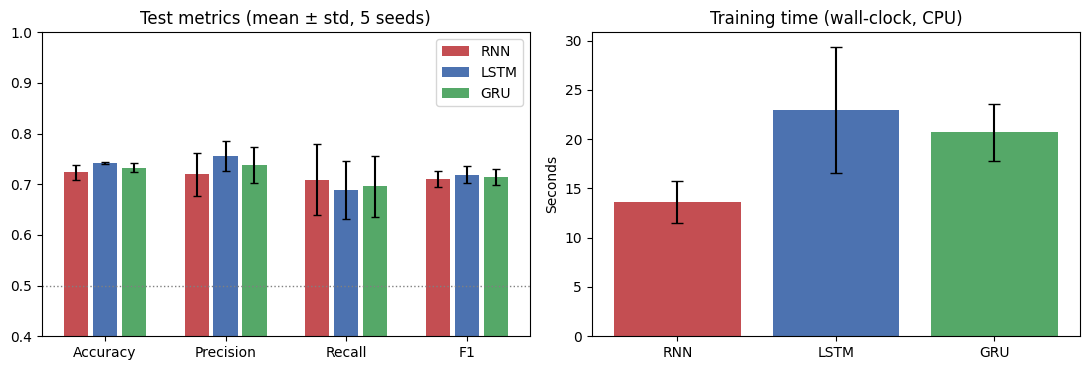

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
w = 0.2; x = np.arange(4); cols = ["#C44E52", "#4C72B0", "#55A868"]
for i, m in enumerate(order):
    ax[0].bar(x + (i-1)*w*1.2, [mean.loc[m,k] for k in ["Accuracy","Precision","Recall","F1"]], w,
              yerr=[std.loc[m,k] for k in ["Accuracy","Precision","Recall","F1"]], capsize=3, label=m, color=cols[i])
ax[0].set_xticks(x); ax[0].set_xticklabels(["Accuracy","Precision","Recall","F1"]); ax[0].set_ylim(0.4, 1.0)
ax[0].axhline(0.5, color="grey", ls=":", lw=1); ax[0].set_title("Test metrics (mean ± std, 5 seeds)"); ax[0].legend()
ax[1].bar(order, mean["TrainTime_s"], yerr=std["TrainTime_s"], capsize=4, color=cols)
ax[1].set_ylabel("Seconds"); ax[1].set_title("Training time (wall-clock, CPU)")
plt.tight_layout(); plt.savefig("figs/metrics.png", dpi=150); plt.show()

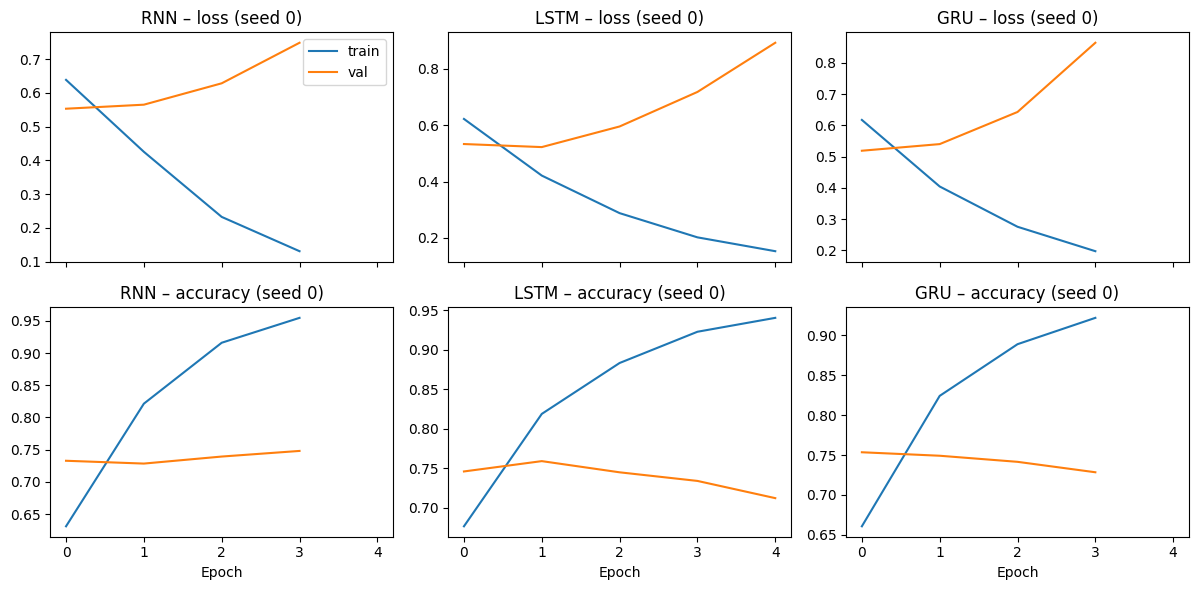

In [9]:
fig, ax = plt.subplots(2, 3, figsize=(12, 6), sharex=True)
for j, m in enumerate(order):
    h = hist[(m, 0)]
    ax[0][j].plot(h["loss"], label="train"); ax[0][j].plot(h["val_loss"], label="val"); ax[0][j].set_title(f"{m} – loss (seed 0)")
    ax[1][j].plot(h["accuracy"], label="train"); ax[1][j].plot(h["val_accuracy"], label="val"); ax[1][j].set_title(f"{m} – accuracy (seed 0)")
    ax[1][j].set_xlabel("Epoch")
ax[0][0].legend(); plt.tight_layout(); plt.savefig("figs/curves.png", dpi=150); plt.show()

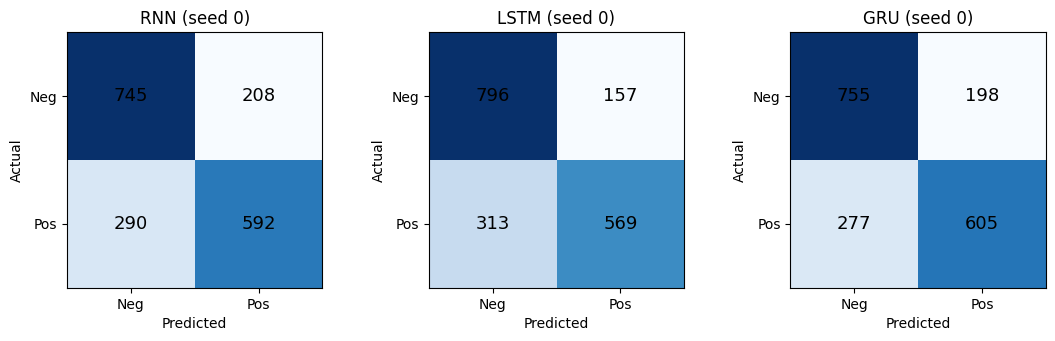

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(11, 3.4))
for j, m in enumerate(order):
    cm = confusion_matrix(y_te, preds[(m, 0)]); ax[j].imshow(cm, cmap="Blues")
    for (a, b), v in np.ndenumerate(cm): ax[j].text(b, a, v, ha="center", va="center", fontsize=13)
    ax[j].set_xticks([0,1]); ax[j].set_yticks([0,1]); ax[j].set_xticklabels(["Neg","Pos"]); ax[j].set_yticklabels(["Neg","Pos"])
    ax[j].set_xlabel("Predicted"); ax[j].set_ylabel("Actual"); ax[j].set_title(f"{m} (seed 0)")
plt.tight_layout(); plt.savefig("figs/confusion.png", dpi=150); plt.show()

## 7. Analysis and conclusion

**Results (mean of 5 seeds, test set of 1,835 tweets):**

| Model | Accuracy | Precision | Recall | F1 | Train time |
|---|---|---|---|---|---|
| RNN | 0.724 | 0.720 | 0.709 | 0.711 | 12 s |
| LSTM | **0.742** | **0.756** | 0.688 | **0.719** | 17 s |
| GRU | 0.733 | 0.738 | 0.696 | 0.714 | 19 s |

**Best model:** LSTM has the highest mean accuracy, precision and F1, and the most stable accuracy across seeds (std 0.003 vs 0.014 for RNN). GRU is second and the plain RNN is last on accuracy.

**Honest reading of the gap:** the F1 differences (0.711 – 0.719) are far smaller than the seed-to-seed standard deviation (about 0.016), so F1 alone does **not** separate the models; the accuracy gain of LSTM over RNN (about 1.8 points) is only about one standard deviation of the RNN. Gated cells give a small, consistent edge, not a dramatic one.

**Why the gap is small:** tweets average about 10 tokens, so there is little long-range dependency for gates to protect against vanishing gradients; the plain RNN copes with short sequences.

**Cost:** the plain RNN trains fastest (about 2.7 s/epoch vs 3.8 s for LSTM and 4.7 s for GRU). Wall-clock totals are noisy because early stopping ends each run after 4–5 epochs, so seconds per epoch is the fairer cost measure. On this CPU, GRU per-epoch time was not lower than LSTM even though it has fewer parameters; this is most likely an implementation and hardware effect.

**Overfitting:** all models reach 92–95% training accuracy while validation loss rises after epoch 1–2 (embeddings are learned from scratch on about 6,400 tweets). Early stopping restores the best epoch. Pre-trained embeddings (GloVe), stronger regularisation, or a bidirectional layer would likely help more than changing the cell type.

**Supplementary experiment:** the same pipeline on 2,000 long movie reviews (NLTK `movie_reviews`, 300 tokens) was also run (see `supp_movie_reviews/`). All three models stayed near chance (accuracy 0.51–0.55), showing that with very little data and long sequences, training recurrent models from scratch is not effective.